In [1]:
import os
import time
import math
import json
import random
import pandas as pd
import numpy as np
import scipy as sp
import pylab as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression

In [2]:
%load_ext autoreload
%autoreload 2
import src.count_utils as utils

In [3]:
import jupyter_black

jupyter_black.load()

In [4]:
plt.style.use("../src/mpl_style.txt")

### Excess word list with frequency cutoff (non-lemmatized)
To determine the optimal rare word list that yields the best LLM use estimate,
we try different frequency cutoffs. The base list consists of all excess style 
words from the 2024 pubmed data. For each cutoff value, only words with frequency 
lower than the cutoff (average 2024) are considered into the list 
of rare words. 

In this version, word lemmata are being ignored and each 
version of a word is treated as a separate entity, e.g "delves" != "delve"
This could be a meaningful difference, because LLMs might have preferences
for certain versions of a word, but not others (how does tokenization work 
for ChatGPT? is the base token for "delve", "delves", "delving" the same?
is this relevant? despite having the same base tokens, different variants
occurr in different semantic and syntactic contexts, so to differentiate
between variants could still be informative, despite being based on the 
same token)

Procedure:
- get all 2024 excess words from the previous paper 
- compute the non-lemmatized average 2024 frequencies for the excess words 
(if they are present in the section vocabulary)
- filter list to only include words with average 2024/2025 frequency below cutoff
- group counts for all words in list
- use new counts to compute frequency, diffs, ratios and projection 
- repeat for every cutoff and section

Open questions:
- should there be a lower bound for frequencies (i.e. 1e-4) as there was in the 
paper? The excess words were determined with a lower bound, so they already 
exclude artefacts

In [5]:
VERSION = "research-article_aimrd_f"
BASELINE = "baseline_2026-01-23"
RESULTS_PATH = os.path.join("../data/results/", BASELINE, VERSION)
secs = next(os.walk(RESULTS_PATH))[1]
# values are either "" or a section name, if not "", only use frequs of the given
# section to compute excess word lists to be used for all sections
vocab_version = ""

In [6]:
years = np.arange(2000, 2026)
months = np.arange(1, 13)
with open(os.path.join(RESULTS_PATH, "filters.json")) as f:
    filters = json.load(f)
dates = pd.to_datetime(filters["all_dates"])

In [7]:
excess_words = utils.excess_style_words_2024
len(excess_words)

379

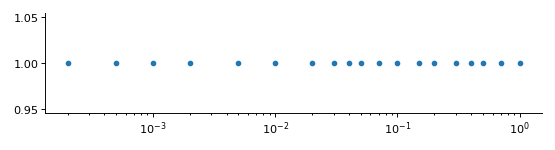

In [8]:
cutoffs = [
    0.0002,
    0.0005,
    0.001,
    0.002,
    0.005,
    0.01,
    0.02,
    0.03,
    0.04,
    0.05,
    0.07,
    0.1,
    0.15,
    0.2,
    0.3,
    0.4,
    0.5,
    0.7,
    1.0,
]
fig, ax = plt.subplots(figsize=(4, 1), layout="constrained")
plt.scatter(cutoffs, [1] * len(cutoffs))
ax.set_xscale("log")

In [9]:
excess_words_cutoff = {}
cutoff_counts = np.zeros((len(secs), len(cutoffs)), dtype=int)

for i, sec in enumerate(secs):
    if not vocab_version == "":
        if not sec == vocab_version:
            continue

    excess_words_cutoff[sec] = {}

    X = sp.sparse.load_npz(os.path.join(RESULTS_PATH, sec, f"count_{sec}.pkl.npz"))

    words = np.load(
        os.path.join(RESULTS_PATH, sec, f"words_{sec}.pkl.npy"), allow_pickle=True
    )

    ind_words = np.isin(words, excess_words)
    ind = dates.year == 2024

    counts = np.array(np.sum(X[ind, :][:, ind_words], axis=0)).ravel()
    totals = np.sum(ind)

    freqs_2024 = (counts + 1) / (totals + 1)

    for j, cutoff in enumerate(cutoffs):

        ind_excess = freqs_2024 < cutoff

        cutoff_counts[i, j] = np.sum(ind_excess)
        excess_words_cutoff[sec][cutoff] = words[ind_words][ind_excess]

    # collect number of papers per year
    if sec == "abstract":
        totals_yearly = {}
        for year in range(2018, 2026):
            totals_yearly[year] = np.sum(dates.year == year)


pd.DataFrame(cutoff_counts, columns=cutoffs, index=secs)

,0.0002,0.0005,0.0010,0.0020,0.0050,0.0100,0.0200,0.0300,0.0400,0.0500,0.0700,0.1000,0.1500,0.2000,0.3000,0.4000,0.5000,0.7000,1.0000
full,0,0,0,14,53,102,154,181,198,211,232,251,278,296,318,330,343,363,379
methods,31,75,119,162,214,240,276,303,315,324,336,343,348,355,361,366,372,376,379
discussion,0,2,25,53,120,172,204,234,244,255,279,297,320,334,347,361,366,377,379
results,9,31,62,109,170,210,242,260,280,287,306,325,338,346,360,366,371,376,379
introduction,0,11,41,85,145,194,235,263,281,292,307,324,341,346,365,371,375,377,379
abstract,25,66,122,166,224,252,294,312,323,332,343,355,365,371,376,378,378,379,379


In [10]:
excess_words_cutoff.keys()

dict_keys(['full', 'methods', 'discussion', 'results', 'introduction', 'abstract'])

In [11]:
totals_yearly

{2018: np.int64(95811),
 2019: np.int64(104737),
 2020: np.int64(127346),
 2021: np.int64(150761),
 2022: np.int64(159584),
 2023: np.int64(145298),
 2024: np.int64(151672),
 2025: np.int64(160909)}

In [12]:
freqs_dfs = {}

for sec in secs:
    if vocab_version == "":
        freqs_dfs[sec] = utils.get_cutoff_frequency(
            RESULTS_PATH,
            sec,
            excess_words_cutoff[sec],
            lemmatized="_non-lemmatized",
        )
    else:
        freqs_dfs[sec] = utils.get_cutoff_frequency(
            RESULTS_PATH,
            sec,
            excess_words_cutoff[vocab_version],
            lemmatized=f"_non-lemmatized_{vocab_version}_only",
        )

loading cutoff freqs
loading cutoff freqs
loading cutoff freqs
loading cutoff freqs
loading cutoff freqs
loading cutoff freqs


In [13]:
totals = [totals_yearly[y] for y in freqs_dfs["abstract"]["time"]]

In [14]:
p = 0.5
q = 0.7
n = 120000
var_p = p * (1 - p) / n
math.sqrt(utils.var_g(p, var_p, q, n)[0][0])

0.00316227766016838

In [15]:
utils.se(p, q, n, "binomial")

0.00316227766016838

In [16]:
for sec in secs:
    p = freqs_dfs[sec]["projection"]
    q = freqs_dfs[sec]["frequency"]
    reg_se = freqs_dfs[sec]["regression se"]
    freqs_dfs[sec]["binomial se"] = list(map(lambda p, n: p * (1 - p) / n, p, totals))
    freqs_dfs[sec]["binomial se (ds)"] = list(
        map(utils.se, p, q, totals, ["binomial"] * len(p))
    )
    freqs_dfs[sec]["regression se (ds)"] = list(
        map(utils.se, p, q, totals, ["regression"] * len(p), reg_se)
    )
    freqs_dfs[sec]["combined se (ds)"] = list(
        map(utils.se, p, q, totals, ["both"] * len(p), reg_se)
    )
    freqs_dfs[sec]["regression se (delta)"] = list(
        map(utils.se, p, q, totals, ["regression"] * len(p), reg_se, ["delta"] * len(p))
    )

In [17]:
# filter out cutoffs with too high base frequency
freqs_dfs_filtered = {}
for sec in secs:
    remove = freqs_dfs[sec][freqs_dfs[sec]["projection"] >= 0.999]["cutoff"].unique()
    freqs_dfs_filtered[sec] = freqs_dfs[sec][
        freqs_dfs[sec]["cutoff"].apply(lambda x: x not in remove)
    ].copy()

In [18]:
freqs_dfs["introduction"]

,cutoff,time,frequency,projection,diff,usage estimate,regression se,binomial se,binomial se (ds),regression se (ds),combined se (ds),regression se (delta)
0,0.0002,2018,0.000010,0.000010,3.852770e-08,3.852810e-08,4.909656e-07,1.085311e-10,0.000015,0.000010,0.000015,0.000010
1,0.0005,2018,0.001837,0.001771,6.578582e-05,6.590254e-05,9.487781e-05,1.845308e-08,0.000194,0.000168,0.000216,0.000168
2,0.0010,2018,0.010270,0.009815,4.549646e-04,4.594744e-04,5.317486e-04,1.014373e-07,0.000460,0.000630,0.000707,0.000624
3,0.0020,2018,0.029328,0.028402,9.266512e-04,9.537389e-04,1.191651e-03,2.880146e-07,0.000787,0.001348,0.001456,0.001310
4,0.0050,2018,0.089540,0.087867,1.673214e-03,1.834396e-03,1.951563e-03,8.365027e-07,0.001423,0.002363,0.002566,0.002159
...,...,...,...,...,...,...,...,...,...,...,...,...
147,0.3000,2025,0.990448,0.995236,-4.788411e-03,-1.005227e+00,8.137659e-04,2.946275e-08,0.088386,0.346321,0.353778,0.000849
148,0.4000,2025,0.992455,0.997786,-5.330626e-03,-2.407730e+00,3.254187e-04,1.372864e-08,0.204984,0.510273,0.541205,0.000390
149,0.5000,2025,0.992965,0.998478,-5.512708e-03,-3.621349e+00,4.238890e-04,9.446103e-09,0.325254,1.294104,1.327313,0.000472
150,0.7000,2025,0.993170,0.998914,-5.743828e-03,-5.288604e+00,3.113532e-04,6.742301e-09,0.511648,1.812683,1.873997,0.000373


In [19]:
freqs_dfs_filtered["introduction"]

,cutoff,time,frequency,projection,diff,usage estimate,regression se,binomial se,binomial se (ds),regression se (ds),combined se (ds),regression se (delta)
0,0.0002,2018,0.000010,0.000010,3.852770e-08,3.852810e-08,4.909656e-07,1.085311e-10,0.000015,0.000010,0.000015,0.000010
1,0.0005,2018,0.001837,0.001771,6.578582e-05,6.590254e-05,9.487781e-05,1.845308e-08,0.000194,0.000168,0.000216,0.000168
2,0.0010,2018,0.010270,0.009815,4.549646e-04,4.594744e-04,5.317486e-04,1.014373e-07,0.000460,0.000630,0.000707,0.000624
3,0.0020,2018,0.029328,0.028402,9.266512e-04,9.537389e-04,1.191651e-03,2.880146e-07,0.000787,0.001348,0.001456,0.001310
4,0.0050,2018,0.089540,0.087867,1.673214e-03,1.834396e-03,1.951563e-03,8.365027e-07,0.001423,0.002363,0.002566,0.002159
...,...,...,...,...,...,...,...,...,...,...,...,...
146,0.2000,2025,0.978976,0.973040,5.935931e-03,2.201746e-01,1.861335e-03,1.630316e-07,0.017674,0.055450,0.056666,0.001895
147,0.3000,2025,0.990448,0.995236,-4.788411e-03,-1.005227e+00,8.137659e-04,2.946275e-08,0.088386,0.346321,0.353778,0.000849
148,0.4000,2025,0.992455,0.997786,-5.330626e-03,-2.407730e+00,3.254187e-04,1.372864e-08,0.204984,0.510273,0.541205,0.000390
149,0.5000,2025,0.992965,0.998478,-5.512708e-03,-3.621349e+00,4.238890e-04,9.446103e-09,0.325254,1.294104,1.327313,0.000472


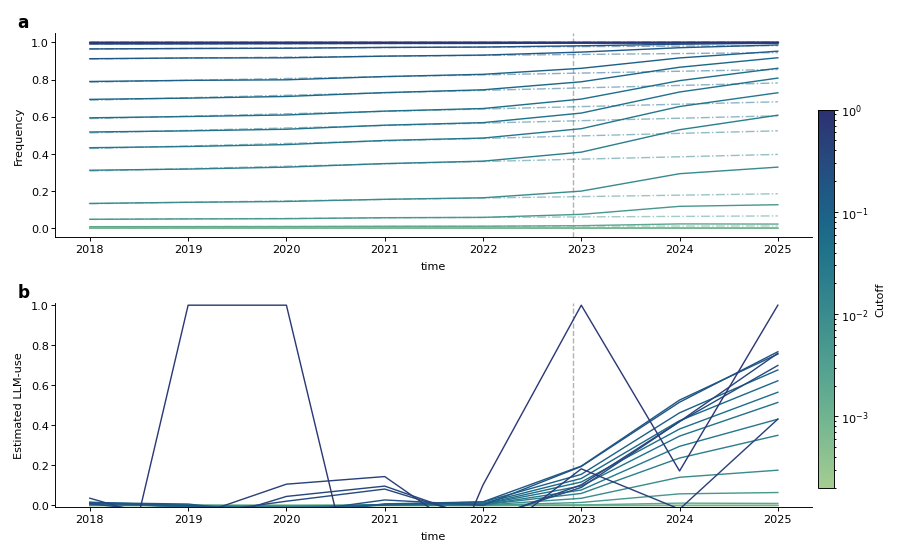

In [20]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), layout="constrained")

hue_norm = LogNorm()
palette = "crest"
sec = "full"
data = freqs_dfs[sec].copy()
data["time"] = list(map(int, data["time"]))
for i, var in enumerate(["frequency", "usage estimate"]):
    ax = axs.flatten()[i]

    ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
    sns.lineplot(
        data=data,
        x="time",
        y=var,
        hue="cutoff",
        hue_norm=hue_norm,
        palette=palette,
        ax=ax,
        legend=False,
    )

    if var == "frequency":
        sns.lineplot(
            data=data,
            x="time",
            y="projection",
            hue="cutoff",
            hue_norm=LogNorm(),
            palette=palette,
            ax=ax,
            alpha=0.5,
            linestyle="-.",
            legend=False,
        )

    if var == "usage estimate":
        ax.set_ylim(-0.01, 1.01)

    if var == "usage estimate":
        sm = plt.cm.ScalarMappable(cmap=palette, norm=hue_norm)
        cax = fig.add_axes(
            [
                ax.get_position().x1 + 0.1,
                ax.get_position().y0,
                0.02,
                ax.get_position().height * 2,
            ]
        )
        cbar = ax.figure.colorbar(sm, cax=cax)
        cbar.set_label("Cutoff", rotation=90)

axs[0].set_ylabel("Frequency")
axs[1].set_ylabel("Estimated LLM-use")

axs[0].text(
    -0.05,
    1.1,
    "a",
    transform=axs[0].transAxes,
    fontsize=9,
    fontweight="bold",
    va="top",
)
axs[1].text(
    -0.05,
    1.1,
    "b",
    transform=axs[1].transAxes,
    fontsize=9,
    fontweight="bold",
    va="top",
)
plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        f"5y_all_cutoffs_{sec}_lower_bound_non_lemmatized_{vocab_version}.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

In [21]:
"""freqs_df_agg = {}
for sec in secs:
    df = freqs_dfs[sec].copy()
    df["time"] = list(map(math.floor, df["time"]))
    df = df.groupby(["time", "cutoff"]).mean().reset_index()
    freqs_df_agg[sec] = df"""

'freqs_df_agg = {}\nfor sec in secs:\n    df = freqs_dfs[sec].copy()\n    df["time"] = list(map(math.floor, df["time"]))\n    df = df.groupby(["time", "cutoff"]).mean().reset_index()\n    freqs_df_agg[sec] = df'

In [22]:
"""freqs_df_filtered_agg = {}
for sec in secs:
    df = freqs_dfs_filtered[sec].copy()
    df["time"] = list(map(math.floor, df["time"]))
    df = df.groupby(["time", "cutoff"]).mean().reset_index()
    freqs_df_filtered_agg[sec] = df"""

'freqs_df_filtered_agg = {}\nfor sec in secs:\n    df = freqs_dfs_filtered[sec].copy()\n    df["time"] = list(map(math.floor, df["time"]))\n    df = df.groupby(["time", "cutoff"]).mean().reset_index()\n    freqs_df_filtered_agg[sec] = df'

In [23]:
freqs_dfs["abstract"][freqs_dfs["abstract"]["time"] == 2025]

,cutoff,time,frequency,projection,diff,usage estimate,regression se,binomial se,binomial se (ds),regression se (ds),combined se (ds),regression se (delta)
133,0.0002,2025,0.002747,0.001837,0.000910,0.000911,0.000141,1.139601e-08,0.000169,0.000192,0.000220,0.000192
134,0.0005,2025,0.014157,0.007948,0.006209,0.006259,0.000448,4.900089e-08,0.000371,0.000538,0.000582,0.000536
135,0.0010,2025,0.051140,0.025909,0.025231,0.025902,0.001318,1.568457e-07,0.000689,0.001433,0.001487,0.001428
136,0.0020,2025,0.107700,0.055101,0.052599,0.055666,0.002247,3.235694e-07,0.000996,0.002390,0.002456,0.002376
137,0.0050,2025,0.272332,0.145101,0.127231,0.148826,0.003966,7.709142e-07,0.001565,0.004157,0.004248,0.004119
138,0.0100,2025,0.401715,0.217433,0.184283,0.235485,0.006372,1.057465e-06,0.001857,0.006418,0.006496,0.006488
139,0.0200,2025,0.638394,0.418129,0.220265,0.378546,0.014115,1.512017e-06,0.002442,0.015215,0.015272,0.014166
140,0.0300,2025,0.740147,0.540598,0.199548,0.434366,0.012964,1.543430e-06,0.002829,0.016138,0.016210,0.013010
141,0.0400,2025,0.799055,0.622640,0.176415,0.467499,0.011627,1.460201e-06,0.003149,0.016620,0.016707,0.011670
142,0.0500,2025,0.847903,0.699809,0.148094,0.493331,0.010326,1.305561e-06,0.003551,0.017682,0.017787,0.010365


In [24]:
freqs_dfs["full"][freqs_dfs["full"]["time"] == "2025"].columns

Index(['cutoff', 'time', 'frequency', 'projection', 'diff', 'usage estimate',
       'regression se', 'binomial se', 'binomial se (ds)',
       'regression se (ds)', 'combined se (ds)', 'regression se (delta)'],
      dtype='object')

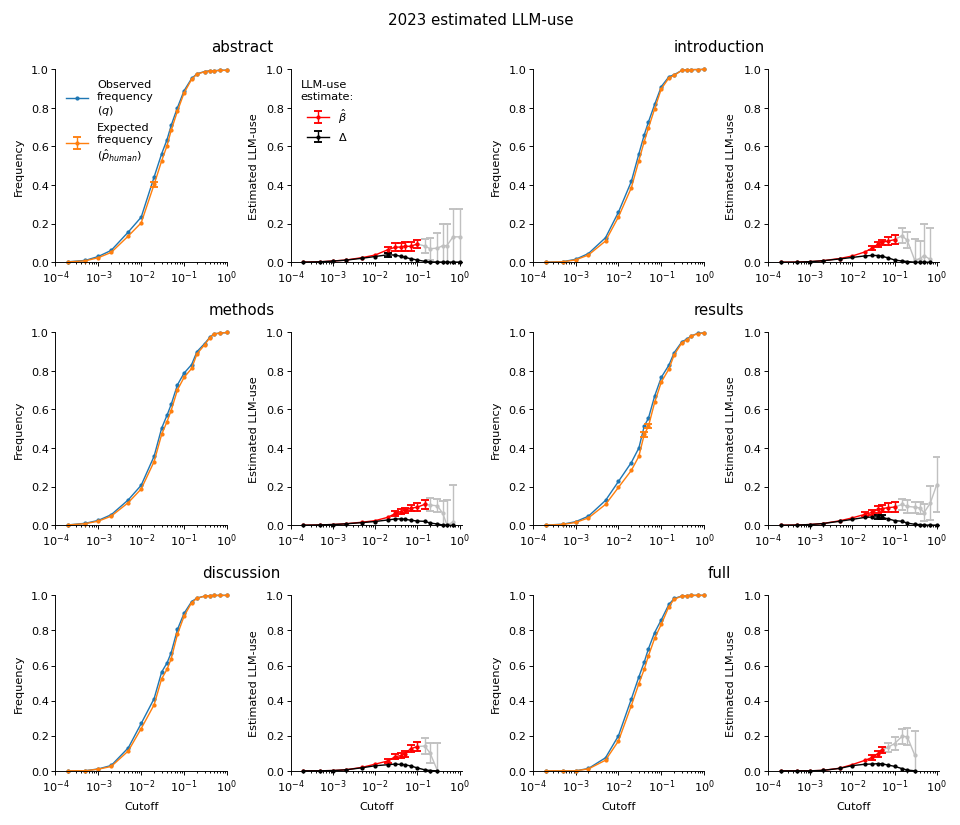

In [25]:
# ensure correct order
sections = ["abstract", "introduction", "methods", "results", "discussion", "full"]
target_year = 2023
se_thr_low = 0.01
se_thr_high = 0.025

fig = plt.figure(figsize=(7, 6), layout="constrained")
subfigs = fig.subfigures(3, 2)  # outer grid

for subfig, sec in zip(subfigs.flat, sections):
    f = freqs_dfs[sec][freqs_dfs[sec]["time"] == target_year]
    f_filt = freqs_dfs_filtered[sec][freqs_dfs_filtered[sec]["time"] == target_year]
    if len(np.where(f_filt["regression se (ds)"] > se_thr_high)[0]) > 0:
        high_error = np.where(f_filt["regression se (ds)"] > se_thr_high)[0][0]
    else:
        high_error = len(f_filt)

    axs = subfig.subplots(1, 2)  # inner grid

    subfig.suptitle(sec)

    # frequency plot
    axs[0].plot(
        f["cutoff"],
        f["frequency"],
        ".-",
        clip_on=False,
        label="Observed\nfrequency\n($q$)",
        markersize=2.5,
    )
    axs[0].errorbar(
        f["cutoff"],
        f["projection"],
        yerr=np.where(
            f["regression se"] > se_thr_low, f["regression se"], np.nan
        ),  # ±1 standard errors
        fmt=".-",  # np.where(yerr >= threshold, yerr, np.nan)
        # ecolor="grey",
        capsize=2,
        label="Expected\nfrequency\n($\\hat{p}_{human}$)",
        clip_on=False,
        markersize=2.5,
    )
    axs[0].set_xscale("log")
    axs[0].set_xlim([1e-4, 1])
    axs[0].set_ylim([0, 1])
    axs[0].set_ylabel("Frequency")
    if sec == "abstract":
        axs[0].legend()
    if sec in ["discussion", "full"]:
        axs[0].set_xlabel("Cutoff")

    # usage estimate plot

    axs[1].errorbar(
        f_filt["cutoff"][high_error - 1 :],
        f_filt["usage estimate"][high_error - 1 :],
        yerr=f_filt["regression se (ds)"][high_error - 1 :],  # ±1 standard errors
        fmt=".-",
        color="silver",
        capsize=2,
        markersize=2.5,
        zorder=0.5,
    )
    axs[1].errorbar(
        f_filt["cutoff"][:high_error],
        f_filt["usage estimate"][:high_error],
        yerr=np.where(
            f_filt["regression se (ds)"][:high_error] > se_thr_low,
            f_filt["regression se (ds)"][:high_error],
            np.nan,
        ),  # ±1 standard errors
        fmt="r.-",
        capsize=2,
        label="$\\hat{\\beta}$",
        markersize=2.5,
    )
    axs[1].errorbar(
        f_filt["cutoff"],
        f_filt["diff"],
        yerr=np.where(
            f_filt["regression se (delta)"] > se_thr_low,
            f_filt["regression se (delta)"],
            np.nan,
        ),  # ±1 standard errors
        fmt="k.-",
        capsize=2,
        label="$\\Delta$",
        clip_on=False,
        markersize=2.5,
    )

    axs[1].set_xscale("log")
    axs[1].set_xlim([1e-4, 1.15])
    axs[1].set_ylim([0, 1])
    axs[1].set_ylabel("Estimated LLM-use")
    if sec == "abstract":
        axs[1].legend(title="LLM-use\nestimate:", loc="upper left")
    if sec in ["discussion", "full"]:
        axs[1].set_xlabel("Cutoff")

plt.suptitle(f"{target_year} estimated LLM-use")
plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        f"5y_{target_year}_lower_bound_non_lemmatized_{vocab_version}.png",
    ),
    dpi=300,
)

In [26]:
len(np.where(f_filt["combined se (ds)"] > se_thr_high)[0])

5

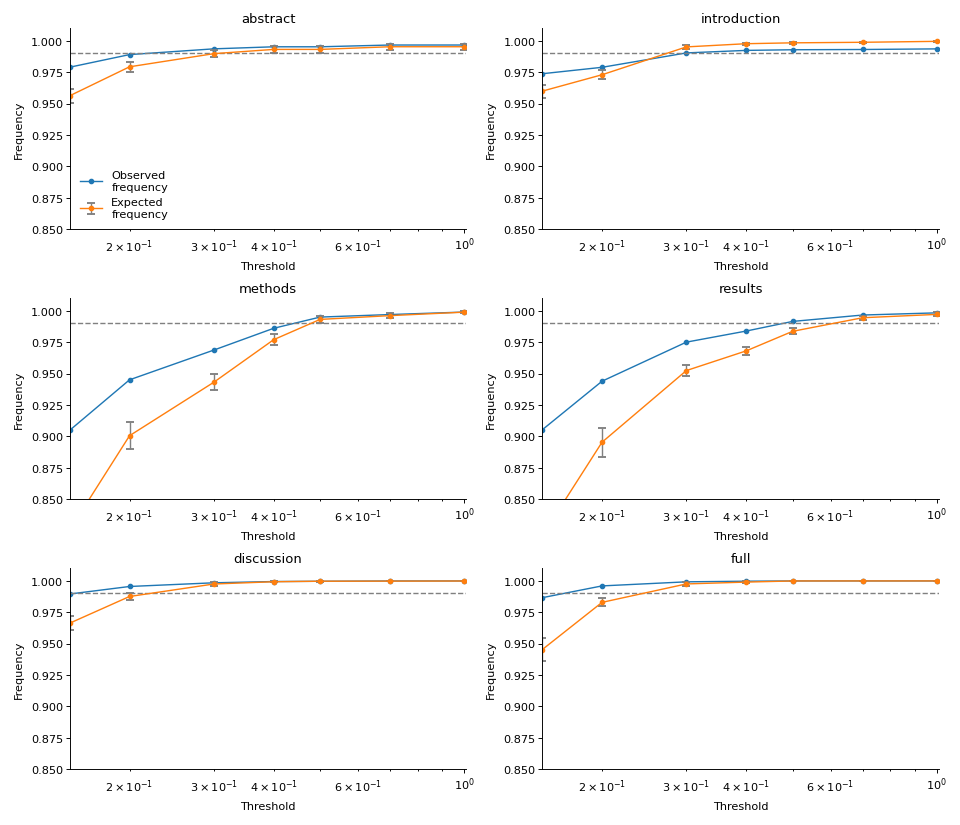

In [27]:
# ensure correct order
sections = ["abstract", "introduction", "methods", "results", "discussion", "full"]

fig, axs = plt.subplots(3, 2, figsize=(7, 6), layout="constrained")

for ax, sec in zip(axs.flat, sections):
    f = freqs_dfs[sec][freqs_dfs[sec]["time"] == 2025]
    f_filt = freqs_dfs_filtered[sec][freqs_dfs_filtered[sec]["time"] == 2025]

    # ax.title(sec)

    # frequency plot
    ax.plot(
        f["cutoff"], f["frequency"], ".-", clip_on=True, label="Observed\nfrequency"
    )
    # axs[0].plot(
    #    f["cutoff"], f["projection"], ".-", clip_on=False, label="Expected\nfrequency"
    # )
    ax.errorbar(
        f["cutoff"],
        f["projection"],
        yerr=list(map(lambda x: x * 2, f["regression se"])),  # ±2 standard errors
        fmt=".-",
        ecolor="grey",
        capsize=2,
        label="Expected\nfrequency",
    )
    ax.axhline(0.99, color="grey", linestyle="--")
    ax.set_xscale("log")
    ax.set_xlim([0.15, 1.01])
    ax.set_ylim([0.85, 1.01])
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Threshold")
    ax.set_title(sec)
    if sec == "abstract":
        ax.legend()

plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        f"close-up_5y_{target_year}_lower_bound_non_lemmatized_{vocab_version}.png",
    ),
    dpi=300,
)

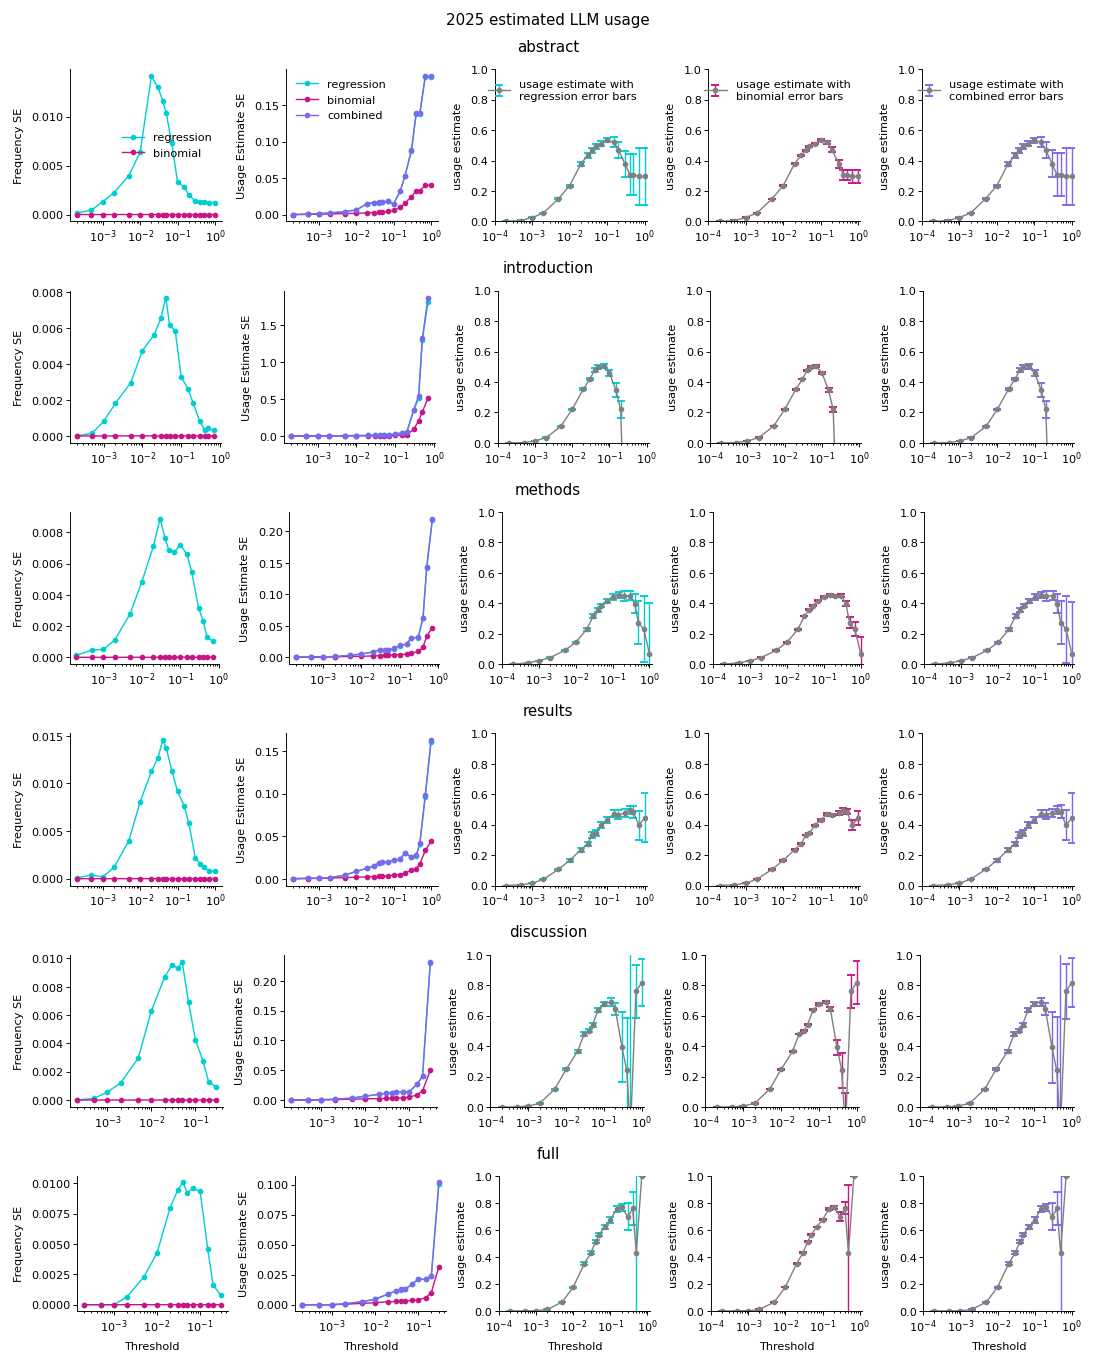

In [28]:
# ensure correct order
sections = ["abstract", "introduction", "methods", "results", "discussion", "full"]
target_year = 2025

fig = plt.figure(figsize=(8, 10), layout="constrained")
subfigs = fig.subfigures(6, 1)  # outer grid

colors = ["darkturquoise", "mediumvioletred", "mediumslateblue"]

for subfig, sec in zip(subfigs, sections):

    f = freqs_dfs[sec][freqs_dfs[sec]["time"] == target_year]
    f_filt = freqs_dfs_filtered[sec][freqs_dfs_filtered[sec]["time"] == target_year]

    axs = subfig.subplots(1, 5)  # inner grid

    subfig.suptitle(sec)

    # frequency errors
    for i, s in enumerate(["regression", "binomial"]):
        axs[0].plot(
            f_filt["cutoff"],
            f_filt[f"{s} se"],
            ".-",
            clip_on=False,
            label=s,
            color=colors[i],
        )

    # axs[0].set_xlim([1e-4, 1])
    # axs[0].set_ylim([0, 1])
    axs[0].set_ylabel("Frequency SE")

    # usage estimate errors
    for i, s in enumerate(["regression", "binomial", "combined"]):
        axs[1].plot(
            f_filt["cutoff"],
            f_filt[f"{s} se (ds)"],
            ".-",
            clip_on=False,
            label=s,
            color=colors[i],
        )

    # axs[1].set_xlim([1e-4, 1])
    # axs[1].set_ylim([0, 1])
    axs[1].set_ylabel("Usage Estimate SE")

    # usage estimate plot
    for i, s in enumerate(["regression", "binomial", "combined"]):
        axs[i + 2].errorbar(
            f["cutoff"],
            f["usage estimate"],
            yerr=f[f"{s} se (ds)"],  # ±1 standard errors
            fmt=".-",
            color="grey",
            ecolor=colors[i],
            capsize=2,
            label=f"usage estimate with\n{s} error bars",
            # clip_on=False,
        )
        axs[i + 2].set_xlim([1e-4, 1.15])
        axs[i + 2].set_ylim([0, 1])
        axs[i + 2].set_ylabel("usage estimate")

    for i in range(5):
        axs[i].set_xscale("log")
        if sec == "abstract":
            axs[i].legend()
        if sec == "full":
            axs[i].set_xlabel("Threshold")


plt.suptitle(f"{target_year} estimated LLM usage")

plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        f"error_comp_5y_{target_year}_lower_bound_non_lemmatized_{vocab_version}.png",
    ),
    dpi=300,
)

find the cutoff yielding the maximum usage estimate (given that p<0.999 and the error<0.025) for each year and section.
Use the cutoff that produces the maximum for 2025 as the default list to compute group frequencies.

In [29]:
# estimates where each year has its own optimized cutoff
max_est = {}
for sec in sections:
    max_est[sec] = {}
    for year in [2023, 2024, 2025]:
        f_filt = freqs_dfs_filtered[sec][freqs_dfs_filtered[sec]["time"] == year]
        if len(np.where(f_filt["regression se (ds)"] > se_thr_high)[0]) > 0:
            high_error = np.where(f_filt["regression se (ds)"] > se_thr_high)[0][0]
        else:
            high_error = len(f_filt)

        i = int(np.argmax(f_filt["usage estimate"][:high_error]))
        max_est[sec][f"usage ({year})"] = list(f_filt["usage estimate"])[i]
        max_est[sec][f"sdev ({year})"] = list(f_filt["regression se (ds)"])[i]
        c = list(f_filt["cutoff"])[i]
        max_est[sec][f"cutoff ({year})"] = c
        max_est[sec][f"excess words ({year})"] = len(excess_words_cutoff[sec][c])

In [30]:
df = pd.DataFrame(max_est).T
df

,usage (2023),sdev (2023),cutoff (2023),excess words (2023),usage (2024),sdev (2024),cutoff (2024),excess words (2024),usage (2025),sdev (2025),cutoff (2025),excess words (2025)
abstract,0.094988,0.019520,0.10,355.0,0.309722,0.017918,0.10,355.0,0.533572,0.014629,0.10,355.0
introduction,0.116784,0.022698,0.10,324.0,0.335740,0.017675,0.07,307.0,0.504129,0.015730,0.07,307.0
methods,0.108566,0.024202,0.15,348.0,0.292507,0.022924,0.15,348.0,0.455218,0.021007,0.15,348.0
results,0.094500,0.024644,0.10,325.0,0.269130,0.023609,0.10,325.0,0.471083,0.022971,0.15,338.0
discussion,0.138598,0.024272,0.10,297.0,0.428480,0.019914,0.10,297.0,0.675299,0.014079,0.10,297.0
full,0.116981,0.018113,0.05,211.0,0.423249,0.021198,0.07,232.0,0.767568,0.023921,0.20,296.0


In [31]:
f_filt = freqs_dfs_filtered[sec][freqs_dfs_filtered[sec]["time"] == 2025]
f_filt[f_filt["cutoff"] == 0.15]["usage estimate"]

145    0.755937
Name: usage estimate, dtype: float64

In [32]:
print(df.to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrrrrrrrr}
\toprule
 & usage (2023) & sdev (2023) & cutoff (2023) & excess words (2023) & usage (2024) & sdev (2024) & cutoff (2024) & excess words (2024) & usage (2025) & sdev (2025) & cutoff (2025) & excess words (2025) \\
\midrule
abstract & 0.09 & 0.02 & 0.10 & 355.00 & 0.31 & 0.02 & 0.10 & 355.00 & 0.53 & 0.01 & 0.10 & 355.00 \\
introduction & 0.12 & 0.02 & 0.10 & 324.00 & 0.34 & 0.02 & 0.07 & 307.00 & 0.50 & 0.02 & 0.07 & 307.00 \\
methods & 0.11 & 0.02 & 0.15 & 348.00 & 0.29 & 0.02 & 0.15 & 348.00 & 0.46 & 0.02 & 0.15 & 348.00 \\
results & 0.09 & 0.02 & 0.10 & 325.00 & 0.27 & 0.02 & 0.10 & 325.00 & 0.47 & 0.02 & 0.15 & 338.00 \\
discussion & 0.14 & 0.02 & 0.10 & 297.00 & 0.43 & 0.02 & 0.10 & 297.00 & 0.68 & 0.01 & 0.10 & 297.00 \\
full & 0.12 & 0.02 & 0.05 & 211.00 & 0.42 & 0.02 & 0.07 & 232.00 & 0.77 & 0.02 & 0.20 & 296.00 \\
\bottomrule
\end{tabular}



In [33]:
f_filt[f_filt["cutoff"] == 0.1]["usage estimate"]

144    0.676471
Name: usage estimate, dtype: float64

In [34]:
df.loc["abstract"]["cutoff (2025)"]

np.float64(0.1)

In [35]:
# estimates where all years use the optimal cutoff for 2025
max_est_fixed = {}
for sec in sections:
    max_est_fixed[sec] = {}

    for year in [2023, 2024, 2025]:
        f_filt = freqs_dfs_filtered[sec][freqs_dfs_filtered[sec]["time"] == year]
        c = df.loc[sec]["cutoff (2025)"]
        f_filt = f_filt[f_filt["cutoff"] == c]

        max_est_fixed[sec][f"usage ({year})"] = np.float64(f_filt["usage estimate"])
        max_est_fixed[sec][f"sdev ({year})"] = np.float64(f_filt["regression se (ds)"])

/tmp/ipykernel_3065326/233810470.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  max_est_fixed[sec][f"usage ({year})"] = np.float64(f_filt["usage estimate"])
/tmp/ipykernel_3065326/233810470.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  max_est_fixed[sec][f"sdev ({year})"] = np.float64(f_filt["regression se (ds)"])


In [36]:
df2 = pd.DataFrame(max_est_fixed).T
df2["cutoff"] = df["cutoff (2025)"]
df2

,usage (2023),sdev (2023),usage (2024),sdev (2024),usage (2025),sdev (2025),cutoff
abstract,0.094988,0.019520,0.309722,0.017918,0.533572,0.014629,0.10
introduction,0.110061,0.019784,0.335740,0.017675,0.504129,0.015730,0.07
methods,0.108566,0.024202,0.292507,0.022924,0.455218,0.021007,0.15
results,0.107776,0.027462,0.295204,0.025805,0.471083,0.022971,0.15
discussion,0.138598,0.024272,0.428480,0.019914,0.675299,0.014079,0.10
full,0.194583,0.046978,0.515509,0.037043,0.767568,0.023921,0.20


In [37]:
print(df2.to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrrr}
\toprule
 & usage (2023) & sdev (2023) & usage (2024) & sdev (2024) & usage (2025) & sdev (2025) & cutoff \\
\midrule
abstract & 0.09 & 0.02 & 0.31 & 0.02 & 0.53 & 0.01 & 0.10 \\
introduction & 0.11 & 0.02 & 0.34 & 0.02 & 0.50 & 0.02 & 0.07 \\
methods & 0.11 & 0.02 & 0.29 & 0.02 & 0.46 & 0.02 & 0.15 \\
results & 0.11 & 0.03 & 0.30 & 0.03 & 0.47 & 0.02 & 0.15 \\
discussion & 0.14 & 0.02 & 0.43 & 0.02 & 0.68 & 0.01 & 0.10 \\
full & 0.19 & 0.05 & 0.52 & 0.04 & 0.77 & 0.02 & 0.20 \\
\bottomrule
\end{tabular}



In [38]:
for sec in secs:
    co1 = max_est[sec]["cutoff (2025)"]
    co1_ind = np.where(np.asarray(cutoffs) == co1)[0][0]
    co2 = cutoffs[co1_ind - 1]
    co3 = cutoffs[co1_ind - 2]
    ew1 = excess_words_cutoff[sec][co1]
    ew2 = excess_words_cutoff[sec][co2]
    ew3 = excess_words_cutoff[sec][co3]
    np.save(
        os.path.join(RESULTS_PATH, sec, f"optimized_excess_words_{sec}.pkl"),
        ew1,
        allow_pickle=True,
    )
    np.save(
        os.path.join(RESULTS_PATH, sec, f"suboptimized_excess_words_{sec}.pkl"),
        ew2,
        allow_pickle=True,
    )
    np.save(
        os.path.join(RESULTS_PATH, sec, f"subsuboptimized_excess_words_{sec}.pkl"),
        ew3,
        allow_pickle=True,
    )
    print(f"{sec}: {len(ew1)}({len(ew2)}) excess words at optimal cutoff {co1}({co2})")

full: 296(278) excess words at optimal cutoff 0.2(0.15)
methods: 348(343) excess words at optimal cutoff 0.15(0.1)
discussion: 297(279) excess words at optimal cutoff 0.1(0.07)
results: 338(325) excess words at optimal cutoff 0.15(0.1)
introduction: 307(292) excess words at optimal cutoff 0.07(0.05)
abstract: 355(343) excess words at optimal cutoff 0.1(0.07)


In [39]:
co1

0.1

In [40]:
i = np.where(np.asarray(cutoffs) == co1)[0][0]
i

np.int64(11)

In [41]:
cutoffs[i - 1]

0.07

In [42]:
excess_words_cutoff["abstract"][max_est["abstract"]["cutoff (2025)"]]

array(['accentuates', 'achieving', 'acknowledges', 'acknowledging',
       'additionally', 'address', 'addresses', 'addressing', 'adept',
       'adhered', 'adhering', 'advancement', 'advancements', 'advancing',
       'advocates', 'advocating', 'affirming', 'afflicted', 'aiding',
       'aims', 'akin', 'align', 'aligning', 'aligns', 'alongside',
       'amidst', 'approach', 'assess', 'assessing', 'assessments',
       'attains', 'attributed', 'augmenting', 'avenue', 'avenues',
       'bolster', 'bolstered', 'bolstering', 'broader', 'burgeoning',
       'capabilities', 'capitalizing', 'categorized', 'categorizes',
       'categorizing', 'challenge', 'challenges', 'combating',
       'commendable', 'compelling', 'complex', 'complicates',
       'complicating', 'comprehending', 'comprehensive', 'comprising',
       'conditions', 'consequently', 'consolidates', 'contributing',
       'conversely', 'correlating', 'crafted', 'crafting', 'crucial',
       'culminating', 'customizing', 'delin

In [43]:
# get excess words sorted by abstract freqs
sec = "abstract"
X = sp.sparse.load_npz(os.path.join(RESULTS_PATH, sec, f"count_{sec}.pkl.npz"))

words = np.load(
    os.path.join(RESULTS_PATH, sec, f"words_{sec}.pkl.npy"), allow_pickle=True
)

ind_words = np.isin(words, excess_words)
ind = dates.year == 2024

counts = np.array(np.sum(X[ind, :][:, ind_words], axis=0)).ravel()
totals = np.sum(ind)

freqs_2024 = (counts + 1) / (totals + 1)

In [44]:
ew_df = pd.DataFrame(zip(freqs_2024, words[ind_words]), columns=["freq", "ew"])
ew_df = ew_df.sort_values("freq")
print(list(ew_df["ew"]))

['revolves', 'upholding', 'dependability', 'attains', 'endeavours', 'scrutinizing', 'garnering', 'consolidates', 'encapsulates', 'merges', 'accentuates', 'grappling', 'acknowledges', 'furnish', 'delving', 'solidify', 'uphold', 'urging', 'surmount', 'juxtaposed', 'customizing', 'propelling', 'detrimentally', 'interconnectedness', 'equipping', 'realms', 'categorizes', 'commendable', 'embracing', 'crafting', 'substantiates', 'bolstered', 'pioneers', 'burgeoning', 'unlocking', 'capitalizing', 'heighten', 'gauged', 'emulating', 'refines', 'uncharted', 'unparalleled', 'crafted', 'adept', 'scrutinize', 'swiftly', 'emulation', 'excels', 'surged', 'harnesses', 'revolutionizing', 'spurred', 'streamlines', 'expediting', 'dependable', 'bolstering', 'empowers', 'groundbreaking', 'illuminating', 'hinting', 'discerning', 'afflicted', 'inquiries', 'scrutinized', 'detailing', 'discerned', 'surpass', 'overlook', 'streamlining', 'emphasising', 'delineates', 'seamless', 'overlooking', 'seamlessly', 'hinge

In [45]:
ew_df[ew_df["freq"] >= 0.1]

,freq,ew
274,0.105800,primary
29,0.106802,assessed
186,0.112986,impact
247,0.115017,outcomes
76,0.115340,demonstrated
60,0.120615,conducted
4,0.121347,across
289,0.124801,research
377,0.137625,within
291,0.143354,revealed
